# 01. ETS VWAP 기초 EDA

`raw.krx_ets_daily`에서 VWAP 기반 타겟을 설계하기 전, 데이터 구조와 빈티지 전환 문제를 확인한다.

## 주요 변수 정의

| 변수 | 의미 |
|---|---|
| `trd_dd` | KRX 거래일 |
| `isu_code` | KAU 빈티지 코드. 예: `KAU20` |
| `clsprc` | 종가, KRW/톤 |
| `acc_trdvol` | 누적 거래량, 톤 |
| `acc_trdval` | 누적 거래대금, KRW |
| `vwap` | 거래량가중평균가, KRW/톤 |
| `is_trade_day` | 거래량과 VWAP가 모두 0보다 큰 실제 거래 관측치 |
| `vwap_logret_1obs` | 같은 빈티지 안에서 직전 실제 거래 관측치 대비 VWAP 로그수익률 |


In [ ]:
# 1. 환경 설정
from pathlib import Path
import os
import warnings
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore", category=RuntimeWarning)

# 프로젝트 경로 설정
if Path('/mnt/hgfs/Windows/Climate').exists():
    PROJECT_ROOT = Path('/mnt/hgfs/Windows/Climate')
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = c:\Arch Linux\Climate


In [ ]:
# 2. DB 연결 확인
load_dotenv(PROJECT_ROOT / '.env')

required_keys = ['DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD']
missing = [key for key in required_keys if not os.getenv(key)]
if missing:
    raise RuntimeError(f'필수 DB 환경변수 없음: {missing}')

user = os.getenv('DB_USER')
password = quote_plus(os.getenv('DB_PASSWORD'))
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db = os.getenv('DB_NAME')

engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}')

with engine.connect() as conn:
    current_db = conn.execute(text('select current_database()')).scalar()

print('DB 연결 확인:', current_db)

DB 연결 확인: allowance


In [70]:
# 3. KRX ETS 일별 원천 테이블 로드
query = """
select
    period,
    trd_dd,
    isu_code,
    clsprc,
    chgh,
    chgh_rt,
    opr,
    hpr,
    lpr,
    acc_trdvol,
    acc_trdval,
    vwap
from raw.krx_ets_daily
order by trd_dd, isu_code
"""

ets = pd.read_sql(query, engine, parse_dates=['trd_dd'])
ets['isu_year'] = ets['isu_code'].str.extract(r'(\d{2})$')[0].astype('Int64') + 2000
ets['is_trade_day'] = (ets['acc_trdvol'] > 0) & (ets['vwap'] > 0)
ets['vwap_log'] = np.where(ets['vwap'] > 0, np.log(ets['vwap']), np.nan)
ets['vwap_logret_1obs'] = ets.groupby('isu_code')['vwap_log'].diff()

print('행/열:', ets.shape)
ets.head()

행/열: (8213, 16)


,period,trd_dd,isu_code,clsprc,chgh,chgh_rt,opr,hpr,lpr,acc_trdvol,acc_trdval,vwap,isu_year,is_trade_day,vwap_log,vwap_logret_1obs
0,1,2015-01-12,KAU15,8640,780,9.92,7860,8640,7860,1190,9740400,8185,2015,True,9.010058,NaN
1,1,2015-01-12,KAU16,7860,7860,0.00,0,0,0,0,0,0,2016,False,NaN,NaN
2,1,2015-01-12,KAU17,7860,7860,0.00,0,0,0,0,0,0,2017,False,NaN,NaN
3,1,2015-01-13,KAU15,9500,860,9.95,9500,9500,9500,50,475000,9500,2015,True,9.159047,0.148989
4,1,2015-01-13,KAU16,7860,0,0.00,0,0,0,0,0,0,2016,False,NaN,NaN


In [71]:
# 4. 기본 구조 요약
basic_summary = pd.DataFrame({
    '항목': [
        '전체 행 수', '컬럼 수', '시작 거래일', '마지막 거래일',
        '거래일 수', '빈티지 수', '중복 키(trd_dd, isu_code)'
    ],
    '값': [
        len(ets),
        ets.shape[1],
        ets['trd_dd'].min().date(),
        ets['trd_dd'].max().date(),
        ets['trd_dd'].nunique(),
        ets['isu_code'].nunique(),
        int(ets.duplicated(['trd_dd', 'isu_code']).sum()),
    ]
})
basic_summary

,항목,값
0,전체 행 수,8213
1,컬럼 수,16
2,시작 거래일,2015-01-12
3,마지막 거래일,2026-04-23
4,거래일 수,2770
5,빈티지 수,16
6,"중복 키(trd_dd, isu_code)",0


In [72]:
# 5. 결측/0 값 확인
check_cols = ['clsprc', 'chgh', 'chgh_rt', 'opr', 'hpr', 'lpr', 'acc_trdvol', 'acc_trdval', 'vwap']

col_labels = {
    'clsprc': '종가',
    'chgh': '대비',
    'chgh_rt': '등락률',
    'opr': '시가',
    'hpr': '고가',
    'lpr': '저가',
    'acc_trdvol': '누적 거래량',
    'acc_trdval': '누적 거래대금',
    'vwap': '거래량 가중 평균가',
}

quality_summary = pd.DataFrame({
    '컬럼': [col_labels[col] for col in check_cols],
    '원본 컬럼': check_cols,
    '결측치 수': [int(ets[col].isna().sum()) for col in check_cols],
    '0 값 수': [int((ets[col] == 0).sum()) for col in check_cols],
    '0 값 비율': [float((ets[col] == 0).mean()) for col in check_cols],
})

quality_summary

,컬럼,원본 컬럼,결측치 수,0 값 수,0 값 비율
0,종가,clsprc,0,0,0.000000
1,대비,chgh,0,6215,0.756727
2,등락률,chgh_rt,0,6217,0.756971
3,시가,opr,0,5913,0.719956
4,고가,hpr,0,5913,0.719956
5,저가,lpr,0,5913,0.719956
6,누적 거래량,acc_trdvol,0,5828,0.709607
7,누적 거래대금,acc_trdval,0,5828,0.709607
8,거래량 가중 평균가,vwap,0,5828,0.709607


In [73]:
# 6. 빈티지별 거래 기간과 실제 거래일 비율
vintage_summary = (
    ets.groupby('isu_code')
    .agg(
        start_date=('trd_dd', 'min'),
        end_date=('trd_dd', 'max'),
        total_obs=('trd_dd', 'size'),
        trade_obs=('is_trade_day', 'sum'),
        zero_volume_obs=('acc_trdvol', lambda x: int((x == 0).sum())),
        total_volume=('acc_trdvol', 'sum'),
    )
    .reset_index()
)

vintage_summary['trade_obs_ratio'] = (
    vintage_summary['trade_obs'] / vintage_summary['total_obs']
)

vintage_summary_display = vintage_summary.rename(columns={
    'isu_code': '빈티지',
    'start_date': '시작일',
    'end_date': '종료일',
    'total_obs': '전체 관측치',
    'trade_obs': '실제 거래일',
    'zero_volume_obs': '거래량 0일',
    'total_volume': '총 거래량',
    'trade_obs_ratio': '실제 거래일 비율',
})

vintage_summary_display

,빈티지,시작일,종료일,전체 관측치,실제 거래일,거래량 0일,총 거래량,실제 거래일 비율
0,KAU15,2015-01-12,2016-06-30,363,33,330,1620224,0.090909
1,KAU16,2015-01-12,2017-06-30,610,134,476,8993600,0.219672
2,KAU17,2015-01-12,2018-08-09,881,250,631,21754596,0.283768
3,KAU18,2018-01-02,2019-09-30,428,154,274,7520475,0.359813
4,KAU19,2018-11-08,2020-09-11,457,291,166,10511590,0.636761
5,KAU20,2018-11-08,2021-08-10,682,285,397,13974616,0.417889
6,KAU21,2021-01-04,2022-08-11,399,266,133,10402374,0.666667
7,KAU22,2021-01-04,2023-09-01,661,284,377,48141257,0.429652
8,KAU23,2021-01-04,2024-09-03,906,267,639,67971324,0.294702
9,KAU24,2021-01-04,2025-09-01,1145,248,897,72101808,0.216594


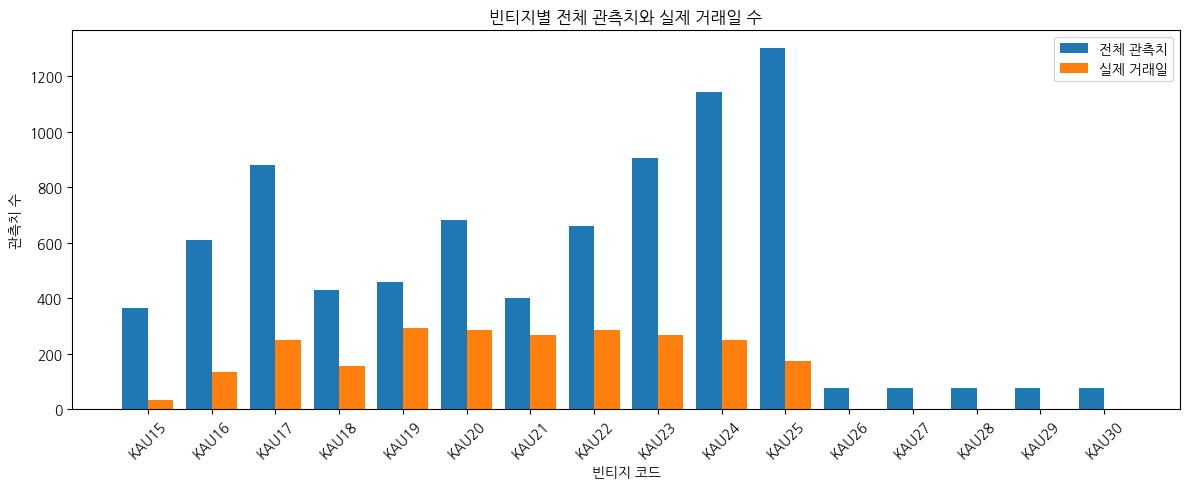

In [74]:
# 7. 빈티지별 전체 관측치와 실제 거래일 비교
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(vintage_summary))
ax.bar(x - 0.2, vintage_summary['total_obs'], width=0.4, label='전체 관측치')
ax.bar(x + 0.2, vintage_summary['trade_obs'], width=0.4, label='실제 거래일')
ax.set_xticks(x)
ax.set_xticklabels(vintage_summary['isu_code'], rotation=45)
ax.set_title('빈티지별 전체 관측치와 실제 거래일 수')
ax.set_xlabel('빈티지 코드')
ax.set_ylabel('관측치 수')
ax.legend()
plt.tight_layout()
plt.show()

In [75]:
# 8. 실제 거래 관측치만 분리
ets_trade = ets[ets['is_trade_day']].copy()
print('전체 관측치:', len(ets))
print('실제 거래 관측치:', len(ets_trade))
print('실제 거래 관측치 비율:', round(len(ets_trade) / len(ets), 4))
ets_trade.head()

전체 관측치: 8213
실제 거래 관측치: 2385
실제 거래 관측치 비율: 0.2904


,period,trd_dd,isu_code,clsprc,chgh,chgh_rt,opr,hpr,lpr,acc_trdvol,acc_trdval,vwap,isu_year,is_trade_day,vwap_log,vwap_logret_1obs
0,1,2015-01-12,KAU15,8640,780,9.92,7860,8640,7860,1190,9740400,8185,2015,True,9.010058,NaN
3,1,2015-01-13,KAU15,9500,860,9.95,9500,9500,9500,50,475000,9500,2015,True,9.159047,0.148989
6,1,2015-01-14,KAU15,9510,10,0.11,9510,9510,9510,100,951000,9510,2015,True,9.160099,0.001052
12,1,2015-01-16,KAU15,9610,30,0.31,9610,9610,9610,40,384400,9610,2015,True,9.170560,NaN
549,1,2015-10-07,KAU15,11300,1000,9.71,11300,11300,11300,12000,135600000,11300,2015,True,9.332558,NaN


In [76]:
# 9. 같은 날짜에 몇 개 빈티지가 상장/거래됐는지 확인
# listed_vintage_count: 해당 날짜의 raw 테이블에 존재하는 빈티지 수
# traded_vintage_count: 해당 날짜의 거래량과 VWAP가 모두 0보다 큰 빈티지 수

daily_overlap = (
    ets.groupby('trd_dd')
    .agg(
        listed_vintage_count=('isu_code', 'nunique'),
        traded_vintage_count=('is_trade_day', 'sum'),
    )
    .reset_index()
)

total_days = len(daily_overlap)

overlap_key_stats = pd.DataFrame({
    '항목': [
        '전체 거래일 수',
        '상장 빈티지가 2개 이상인 날짜 수',
        '실제 거래 빈티지가 0개인 날짜 수',
        '실제 거래 빈티지가 1개인 날짜 수',
        '실제 거래 빈티지가 2개 이상인 날짜 수',
        '하루 최대 실제 거래 빈티지 수',
    ],
    '값': [
        total_days,
        int((daily_overlap['listed_vintage_count'] >= 2).sum()),
        int((daily_overlap['traded_vintage_count'] == 0).sum()),
        int((daily_overlap['traded_vintage_count'] == 1).sum()),
        int((daily_overlap['traded_vintage_count'] >= 2).sum()),
        int(daily_overlap['traded_vintage_count'].max()),
    ],
})

overlap_key_stats['비율'] = [
    1.0,
    (daily_overlap['listed_vintage_count'] >= 2).mean(),
    (daily_overlap['traded_vintage_count'] == 0).mean(),
    (daily_overlap['traded_vintage_count'] == 1).mean(),
    (daily_overlap['traded_vintage_count'] >= 2).mean(),
    np.nan,
]

overlap_key_stats.style.format({
    '값': '{:,.0f}',
    '비율': lambda x: '' if pd.isna(x) else f'{x:.1%}',
})

,항목,값,비율
0,전체 거래일 수,"2,770",100.0%
1,상장 빈티지가 2개 이상인 날짜 수,"2,438",88.0%
2,실제 거래 빈티지가 0개인 날짜 수,638,23.0%
3,실제 거래 빈티지가 1개인 날짜 수,"1,880",67.9%
4,실제 거래 빈티지가 2개 이상인 날짜 수,252,9.1%
5,하루 최대 실제 거래 빈티지 수,3,


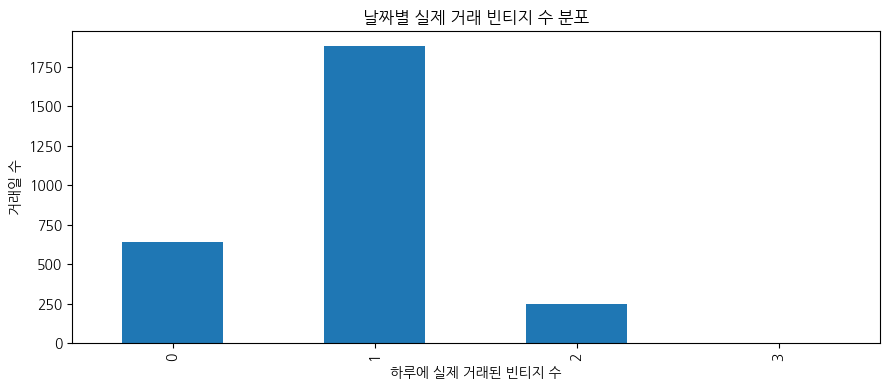

In [77]:
# 10. 날짜별 거래 빈티지 수 분포
fig, ax = plt.subplots(figsize=(9, 4))
daily_overlap['traded_vintage_count'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('날짜별 실제 거래 빈티지 수 분포')
ax.set_xlabel('하루에 실제 거래된 빈티지 수')
ax.set_ylabel('거래일 수')
plt.tight_layout()
plt.show()

In [78]:
# 11. 진단용 daily max volume 대표 시계열
rep_daily_max = (
    ets_trade.sort_values(['trd_dd', 'acc_trdvol', 'acc_trdval'], ascending=[True, False, False])
    .groupby('trd_dd')
    .head(1)
    .sort_values('trd_dd')
    .reset_index(drop=True)
)
rep_daily_max['prev_isu_code'] = rep_daily_max['isu_code'].shift(1)
rep_daily_max['is_rep_changed'] = rep_daily_max['isu_code'].ne(rep_daily_max['prev_isu_code'])
rep_daily_max.loc[rep_daily_max.index[0], 'is_rep_changed'] = False

rep_change_summary = pd.DataFrame({
    '항목': ['대표 관측치 수', '대표 빈티지 변경 횟수', '대표 빈티지 변경 비율'],
    '값': [
        len(rep_daily_max),
        int(rep_daily_max['is_rep_changed'].sum()),
        float(rep_daily_max['is_rep_changed'].mean()),
    ]
})
rep_change_summary

,항목,값
0,대표 관측치 수,2132.000000
1,대표 빈티지 변경 횟수,76.000000
2,대표 빈티지 변경 비율,0.035647


In [79]:
# 12. 대표 빈티지 변경 사례 확인
rep_change_examples = rep_daily_max.loc[
    rep_daily_max['is_rep_changed'],
    ['trd_dd', 'prev_isu_code', 'isu_code', 'vwap', 'acc_trdvol']
].head(20)

rep_change_examples.rename(columns={
    'trd_dd': '거래일',
    'prev_isu_code': '이전 대표 빈티지',
    'isu_code': '현재 대표 빈티지',
    'vwap': 'VWAP',
    'acc_trdvol': '거래량',
})

,거래일,이전 대표 빈티지,현재 대표 빈티지,VWAP,거래량
33,2016-07-04,KAU15,KAU16,15800,80000
94,2017-03-03,KAU16,KAU17,23700,500
98,2017-03-10,KAU17,KAU16,22200,5000
104,2017-03-20,KAU16,KAU17,20200,8000
105,2017-03-21,KAU17,KAU16,21234,153859
117,2017-04-06,KAU16,KAU17,20500,30000
118,2017-04-07,KAU17,KAU16,20545,81719
120,2017-04-11,KAU16,KAU17,20488,137000
121,2017-04-12,KAU17,KAU16,20452,218590
132,2017-04-28,KAU16,KAU17,20500,110000


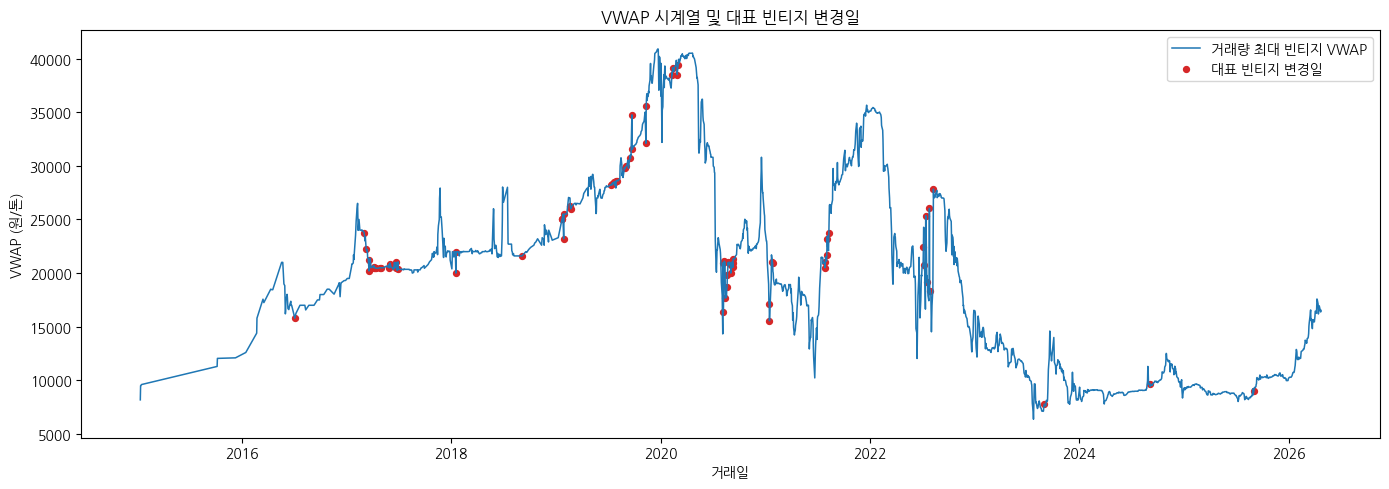

In [91]:
# 13. 진단용 대표 VWAP 시계열
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rep_daily_max['trd_dd'], rep_daily_max['vwap'], linewidth=1.1, label='거래량 최대 빈티지 VWAP')
ax.scatter(
    rep_daily_max.loc[rep_daily_max['is_rep_changed'], 'trd_dd'],
    rep_daily_max.loc[rep_daily_max['is_rep_changed'], 'vwap'],
    s=18,
    color='tab:red',
    label='대표 빈티지 변경일'
)
ax.set_title('VWAP 시계열 및 대표 빈티지 변경일')
ax.set_xlabel('거래일')
ax.set_ylabel('VWAP (원/톤)')
ax.legend()
plt.tight_layout()
plt.show()

In [81]:
# 14. 같은 빈티지 안에서 달력일 기준 타겟 생성 가능 범위 확인
# target_vwap_logret_30d:
#   같은 isu_code에서 기준일 + 30일 이후 첫 실제 거래 VWAP를 사용한 로그수익률
# target_vwap_logret_60d:
#   같은 isu_code에서 기준일 + 60일 이후 첫 실제 거래 VWAP를 사용한 로그수익률
#
# actual_horizon_days_*:
#   기준일과 실제로 사용된 미래 VWAP 날짜 사이의 실제 경과일 수이다.
#   주말, 공휴일, 거래 공백 때문에 목표 30일/60일보다 며칠 길어질 수 있다.

def build_same_vintage_target(df, horizon_days):
    rows = []

    for code, g in df.sort_values('trd_dd').groupby('isu_code'):
        g = g.reset_index(drop=True)
        dates = g['trd_dd']

        for i, row in g.iterrows():
            target_date = row['trd_dd'] + pd.Timedelta(days=horizon_days)

            # 목표일 이후 처음으로 같은 빈티지의 실제 거래 VWAP가 존재하는 날짜를 사용한다.
            j = dates.searchsorted(target_date, side='left')

            if j < len(g):
                future = g.iloc[j]
                price_ratio = future['vwap'] / row['vwap']

                rows.append({
                    'trd_dd': row['trd_dd'],
                    'isu_code': code,
                    'vwap': row['vwap'],
                    'acc_trdvol': row['acc_trdvol'],
                    f'future_date_{horizon_days}d': future['trd_dd'],
                    f'future_vwap_{horizon_days}d': future['vwap'],
                    f'future_acc_trdvol_{horizon_days}d': future['acc_trdvol'],
                    f'actual_horizon_days_{horizon_days}d': (
                        future['trd_dd'] - row['trd_dd']
                    ).days,
                    f'price_ratio_{horizon_days}d': price_ratio,
                    f'target_vwap_logret_{horizon_days}d': np.log(price_ratio),
                })

    return pd.DataFrame(rows)


target_30_same = build_same_vintage_target(ets_trade, 30)
target_60_same = build_same_vintage_target(ets_trade, 60)

coverage_summary = pd.DataFrame({
    'target_name': ['same_vintage_30d', 'same_vintage_60d'],
    'sample_count': [len(target_30_same), len(target_60_same)],
    'start_date': [
        target_30_same['trd_dd'].min(),
        target_60_same['trd_dd'].min(),
    ],
    'end_date': [
        target_30_same['trd_dd'].max(),
        target_60_same['trd_dd'].max(),
    ],
    'actual_elapsed_days_median': [
        target_30_same['actual_horizon_days_30d'].median(),
        target_60_same['actual_horizon_days_60d'].median(),
    ],
    'actual_elapsed_days_p95': [
        target_30_same['actual_horizon_days_30d'].quantile(0.95),
        target_60_same['actual_horizon_days_60d'].quantile(0.95),
    ],
})

coverage_summary_display = coverage_summary.rename(columns={
    'target_name': '타겟',
    'sample_count': '표본 수',
    'start_date': '시작일',
    'end_date': '종료일',
    'actual_elapsed_days_median': '실제 경과일 중앙값',
    'actual_elapsed_days_p95': '실제 경과일 95% 분위',
})

coverage_summary_display.style.format({
    '표본 수': '{:,.0f}',
    '실제 경과일 중앙값': '{:,.1f}',
    '실제 경과일 95% 분위': '{:,.1f}',
})

,타겟,표본 수,시작일,종료일,실제 경과일 중앙값,실제 경과일 95% 분위
0,same_vintage_30d,"2,168",2015-01-12 00:00:00,2026-03-24 00:00:00,30.0,35.0
1,same_vintage_60d,"1,962",2015-01-12 00:00:00,2026-02-20 00:00:00,60.0,64.0


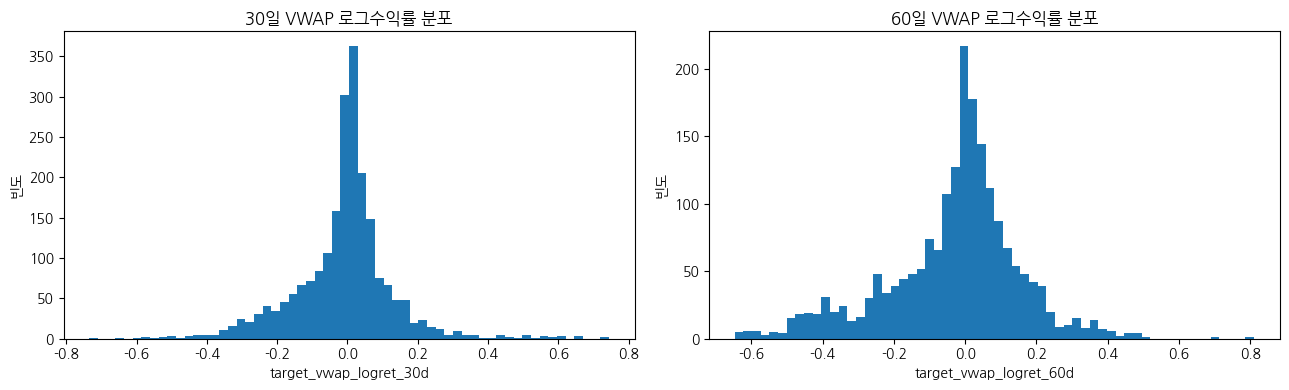

In [82]:
# 15. 동일한 빈티지 기준 30d/60d 수익률 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(target_30_same['target_vwap_logret_30d'].dropna(), bins=60)
axes[0].set_title('30일 VWAP 로그수익률 분포')
axes[0].set_xlabel('target_vwap_logret_30d')
axes[0].set_ylabel('빈도')

axes[1].hist(target_60_same['target_vwap_logret_60d'].dropna(), bins=60)
axes[1].set_title('60일 VWAP 로그수익률 분포')
axes[1].set_xlabel('target_vwap_logret_60d')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

In [83]:
# 16. 빈티지별 타겟 표본 수
same_vintage_target_count = (
    target_30_same.groupby('isu_code').size().rename('target_30d_count').to_frame()
    .join(target_60_same.groupby('isu_code').size().rename('target_60d_count'), how='outer')
    .fillna(0)
    .astype(int)
    .reset_index()
)

same_vintage_target_count_display = same_vintage_target_count.rename(columns={
    'isu_code': '빈티지',
    'target_30d_count': '30일 타겟 표본 수',
    'target_60d_count': '60일 타겟 표본 수',
})

same_vintage_target_count_display

,빈티지,30일 타겟 표본 수,60일 타겟 표본 수
0,KAU15,19,16
1,KAU16,115,98
2,KAU17,233,218
3,KAU18,134,114
4,KAU19,271,249
5,KAU20,264,243
6,KAU21,245,224
7,KAU22,263,241
8,KAU23,246,224
9,KAU24,227,205


In [84]:
# 17. 빈티지별 실제 거래일 대비 타겟 생성률
# target_30d_coverage_rate: 실제 거래일 중 30일 타겟을 만들 수 있었던 비율
# target_60d_coverage_rate: 실제 거래일 중 60일 타겟을 만들 수 있었던 비율

target_coverage_by_vintage = (
    vintage_summary[['isu_code', 'trade_obs']]
    .merge(same_vintage_target_count, on='isu_code', how='left')
    .fillna({'target_30d_count': 0, 'target_60d_count': 0})
)

target_coverage_by_vintage[['target_30d_count', 'target_60d_count']] = (
    target_coverage_by_vintage[['target_30d_count', 'target_60d_count']].astype(int)
)

target_coverage_by_vintage['target_30d_coverage_rate'] = (
    target_coverage_by_vintage['target_30d_count'] / target_coverage_by_vintage['trade_obs']
)
target_coverage_by_vintage['target_60d_coverage_rate'] = (
    target_coverage_by_vintage['target_60d_count'] / target_coverage_by_vintage['trade_obs']
)

target_coverage_by_vintage_display = target_coverage_by_vintage.rename(columns={
    'isu_code': '빈티지',
    'trade_obs': '실제 거래일 수',
    'target_30d_count': '30일 타겟 표본 수',
    'target_30d_coverage_rate': '30일 타겟 생성률',
    'target_60d_count': '60일 타겟 표본 수',
    'target_60d_coverage_rate': '60일 타겟 생성률',
})

target_coverage_by_vintage_display.style.format({
    '실제 거래일 수': '{:,.0f}',
    '30일 타겟 표본 수': '{:,.0f}',
    '60일 타겟 표본 수': '{:,.0f}',
    '30일 타겟 생성률': '{:.1%}',
    '60일 타겟 생성률': '{:.1%}',
})

,빈티지,실제 거래일 수,30일 타겟 표본 수,60일 타겟 표본 수,30일 타겟 생성률,60일 타겟 생성률
0,KAU15,33,19,16,57.6%,48.5%
1,KAU16,134,115,98,85.8%,73.1%
2,KAU17,250,233,218,93.2%,87.2%
3,KAU18,154,134,114,87.0%,74.0%
4,KAU19,291,271,249,93.1%,85.6%
5,KAU20,285,264,243,92.6%,85.3%
6,KAU21,266,245,224,92.1%,84.2%
7,KAU22,284,263,241,92.6%,84.9%
8,KAU23,267,246,224,92.1%,83.9%
9,KAU24,248,227,205,91.5%,82.7%


In [85]:
# 18. 실제 경과일 분포
# 같은 빈티지 안에서 목표 30일/60일 이후 첫 거래일을 사용하므로 실제 경과일은 목표 기간보다 길어질 수 있다.

elapsed_30 = (
    target_30_same['actual_horizon_days_30d']
    .value_counts()
    .sort_index()
    .rename('target_30d_count')
)
elapsed_60 = (
    target_60_same['actual_horizon_days_60d']
    .value_counts()
    .sort_index()
    .rename('target_60d_count')
)

elapsed_days_distribution = (
    pd.concat([elapsed_30, elapsed_60], axis=1)
    .fillna(0)
    .astype(int)
    .rename_axis('actual_elapsed_days')
    .reset_index()
)

elapsed_days_distribution_display = elapsed_days_distribution.rename(columns={
    'actual_elapsed_days': '실제 경과일',
    'target_30d_count': '30일 타겟 표본 수',
    'target_60d_count': '60일 타겟 표본 수',
})

elapsed_days_distribution_display.head(15)

,실제 경과일,30일 타겟 표본 수,60일 타겟 표본 수
0,30,1098,0
1,31,419,0
2,32,408,0
3,33,78,0
4,34,46,0
5,35,31,0
6,36,17,0
7,37,7,0
8,38,6,0
9,39,4,0


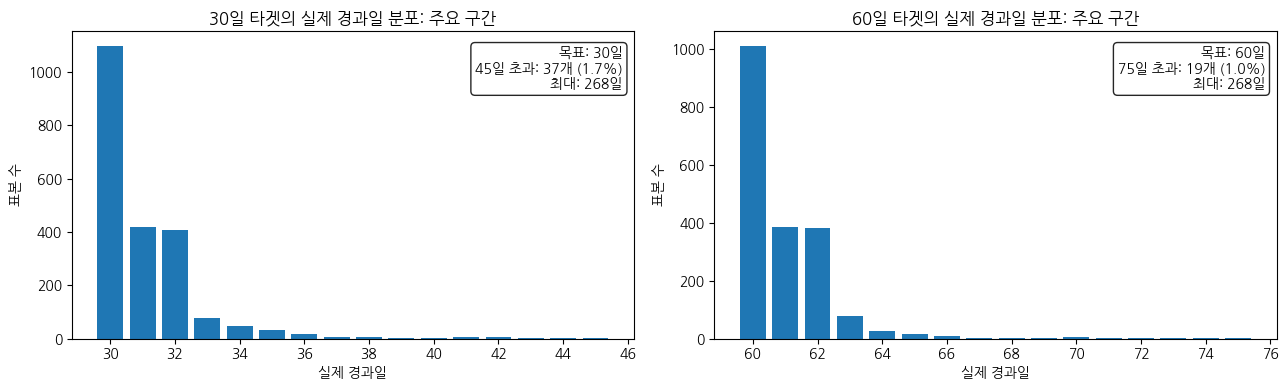

In [86]:
# 19. 실제 경과일 분포 시각화
plot_specs = [
    {
        'counts': elapsed_30,
        'target_days': 30,
        'upper_days': 45,
        'title': '30일 타겟의 실제 경과일 분포: 주요 구간',
    },
    {
        'counts': elapsed_60,
        'target_days': 60,
        'upper_days': 75,
        'title': '60일 타겟의 실제 경과일 분포: 주요 구간',
    },
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, spec in zip(axes, plot_specs):
    counts = spec['counts']
    target_days = spec['target_days']
    upper_days = spec['upper_days']

    counts_main = counts[counts.index <= upper_days]
    long_gap_count = int(counts[counts.index > upper_days].sum())
    total_count = int(counts.sum())
    long_gap_rate = long_gap_count / total_count if total_count else 0
    max_days = int(counts.index.max())

    ax.bar(counts_main.index, counts_main.values)
    ax.set_title(spec['title'])
    ax.set_xlabel('실제 경과일')
    ax.set_ylabel('표본 수')

    ax.text(
        0.98, 0.95,
        f'목표: {target_days}일\n'
        f'{upper_days}일 초과: {long_gap_count:,}개 ({long_gap_rate:.1%})\n'
        f'최대: {max_days:,}일',
        transform=ax.transAxes,
        ha='right',
        va='top',
        bbox={
            'boxstyle': 'round',
            'facecolor': 'white',
            'alpha': 0.85,
        },
    )

plt.tight_layout()
plt.show()

In [87]:
# 20. 빈티지별 30일/60일 수익률 분위 요약
# 각 빈티지가 전체 수익률 분포의 꼬리를 만드는지 확인한다.

def summarize_return_by_vintage(df, return_col, label):
    q = (
        df.groupby('isu_code')[return_col]
        .quantile([0.05, 0.5, 0.95])
        .unstack()
        .rename(columns={0.05: f'{label}_p05', 0.5: f'{label}_median', 0.95: f'{label}_p95'})
    )
    return q

return_summary_by_vintage = (
    summarize_return_by_vintage(target_30_same, 'target_vwap_logret_30d', 'ret_30d')
    .join(summarize_return_by_vintage(target_60_same, 'target_vwap_logret_60d', 'ret_60d'), how='outer')
    .reset_index()
)

return_summary_by_vintage_display = return_summary_by_vintage.rename(columns={
    'isu_code': '빈티지',
    'ret_30d_p05': '30일 수익률 5% 분위',
    'ret_30d_median': '30일 수익률 중앙값',
    'ret_30d_p95': '30일 수익률 95% 분위',
    'ret_60d_p05': '60일 수익률 5% 분위',
    'ret_60d_median': '60일 수익률 중앙값',
    'ret_60d_p95': '60일 수익률 95% 분위',
})

return_summary_by_vintage_display.style.format({
    '30일 수익률 5% 분위': '{:.3f}',
    '30일 수익률 중앙값': '{:.3f}',
    '30일 수익률 95% 분위': '{:.3f}',
    '60일 수익률 5% 분위': '{:.3f}',
    '60일 수익률 중앙값': '{:.3f}',
    '60일 수익률 95% 분위': '{:.3f}',
})

,빈티지,30일 수익률 5% 분위,30일 수익률 중앙값,30일 수익률 95% 분위,60일 수익률 5% 분위,60일 수익률 중앙값,60일 수익률 95% 분위
0,KAU15,-0.192,0.127,0.258,-0.087,0.174,0.344
1,KAU16,-0.149,0.006,0.141,-0.168,0.014,0.219
2,KAU17,-0.119,0.000,0.167,-0.121,0.000,0.198
3,KAU18,-0.055,0.028,0.098,-0.024,0.057,0.167
4,KAU19,-0.345,0.019,0.133,-0.573,0.036,0.206
5,KAU20,-0.309,-0.008,0.326,-0.379,-0.033,0.207
6,KAU21,-0.303,-0.003,0.192,-0.471,-0.017,0.189
7,KAU22,-0.284,-0.088,0.077,-0.476,-0.160,0.029
8,KAU23,-0.256,0.008,0.449,-0.350,0.010,0.361
9,KAU24,-0.148,-0.013,0.104,-0.227,-0.032,0.168


In [88]:
# 21. 30일/60일 극단 수익률 사례 확인
# 극단값이 실제 시장 이벤트인지, 거래량이 작은 날의 VWAP 튐인지 확인하기 위한 표이다.

def get_extreme_returns(df, horizon_days, n=10):
    ret_col = f'target_vwap_logret_{horizon_days}d'
    future_date_col = f'future_date_{horizon_days}d'
    future_vwap_col = f'future_vwap_{horizon_days}d'
    future_vol_col = f'future_acc_trdvol_{horizon_days}d'
    elapsed_col = f'actual_horizon_days_{horizon_days}d'
    ratio_col = f'price_ratio_{horizon_days}d'

    cols = [
        'trd_dd', 'isu_code', 'vwap', 'acc_trdvol',
        future_date_col, future_vwap_col, future_vol_col,
        elapsed_col, ratio_col, ret_col,
    ]

    low = df.nsmallest(n, ret_col)[cols].assign(extreme_type='하위')
    high = df.nlargest(n, ret_col)[cols].assign(extreme_type='상위')
    out = pd.concat([low, high], ignore_index=True)
    out['horizon_days'] = horizon_days
    return out

extreme_returns = pd.concat([
    get_extreme_returns(target_30_same, 30, n=10),
    get_extreme_returns(target_60_same, 60, n=10),
], ignore_index=True)

extreme_returns_display = extreme_returns.rename(columns={
    'horizon_days': '목표 기간',
    'extreme_type': '구분',
    'trd_dd': '기준일',
    'isu_code': '빈티지',
    'vwap': '기준일 VWAP',
    'acc_trdvol': '기준일 거래량',
    'future_date_30d': '30일 미래일',
    'future_vwap_30d': '30일 미래 VWAP',
    'future_acc_trdvol_30d': '30일 미래 거래량',
    'actual_horizon_days_30d': '30일 실제 경과일',
    'price_ratio_30d': '30일 가격 비율',
    'target_vwap_logret_30d': '30일 로그수익률',
    'future_date_60d': '60일 미래일',
    'future_vwap_60d': '60일 미래 VWAP',
    'future_acc_trdvol_60d': '60일 미래 거래량',
    'actual_horizon_days_60d': '60일 실제 경과일',
    'price_ratio_60d': '60일 가격 비율',
    'target_vwap_logret_60d': '60일 로그수익률',
})

extreme_returns_display

,기준일,빈티지,기준일 VWAP,기준일 거래량,30일 미래일,30일 미래 VWAP,30일 미래 거래량,30일 실제 경과일,30일 가격 비율,30일 로그수익률,구분,목표 기간,60일 미래일,60일 미래 VWAP,60일 미래 거래량,60일 실제 경과일,60일 가격 비율,60일 로그수익률
0,2020-07-06,KAU19,29858,62523,2020-08-05,14329.0,28360.0,30.0,0.479905,-0.734167,하위,30,NaT,NaN,NaN,NaN,NaN,NaN
1,2020-07-07,KAU19,29389,59089,2020-08-06,15334.0,7449.0,30.0,0.521760,-0.650548,하위,30,NaT,NaN,NaN,NaN,NaN,NaN
2,2020-12-16,KAU20,28554,11278,2021-01-15,15562.0,13200.0,30.0,0.545002,-0.606965,하위,30,NaT,NaN,NaN,NaN,NaN,NaN
3,2020-07-08,KAU19,29352,93895,2020-08-07,16402.0,62735.0,30.0,0.558803,-0.581957,하위,30,NaT,NaN,NaN,NaN,NaN,NaN
4,2020-12-18,KAU20,30798,6935,2021-01-18,17370.0,19200.0,31.0,0.563998,-0.572705,하위,30,NaT,NaN,NaN,NaN,NaN,NaN
5,2020-07-02,KAU19,30795,237999,2020-08-03,17950.0,17993.0,32.0,0.582887,-0.539762,하위,30,NaT,NaN,NaN,NaN,NaN,NaN
6,2020-12-17,KAU20,29433,17612,2021-01-18,17370.0,19200.0,32.0,0.590154,-0.527372,하위,30,NaT,NaN,NaN,NaN,NaN,NaN
7,2020-07-03,KAU19,29971,53689,2020-08-03,17950.0,17993.0,31.0,0.598912,-0.512640,하위,30,NaT,NaN,NaN,NaN,NaN,NaN
8,2021-05-20,KAU20,17839,102470,2021-06-21,10775.0,224027.0,32.0,0.604014,-0.504158,하위,30,NaT,NaN,NaN,NaN,NaN,NaN
9,2021-05-21,KAU20,17748,33980,2021-06-21,10775.0,224027.0,31.0,0.607111,-0.499044,하위,30,NaT,NaN,NaN,NaN,NaN,NaN


In [89]:
# 22. 거래량 기준을 추가했을 때의 표본 수 변화
# 기준일과 미래일의 거래량이 모두 일정 수준 이상일 때 타겟 표본이 얼마나 남는지 확인한다.

volume_thresholds = [0, 1_000, 10_000, 50_000]
rows = []

for horizon_days, df in [(30, target_30_same), (60, target_60_same)]:
    future_vol_col = f'future_acc_trdvol_{horizon_days}d'
    for threshold in volume_thresholds:
        keep = (df['acc_trdvol'] >= threshold) & (df[future_vol_col] >= threshold)
        rows.append({
            'horizon_days': horizon_days,
            'volume_threshold': threshold,
            'sample_count': int(keep.sum()),
            'sample_rate': float(keep.mean()),
        })

volume_threshold_summary = pd.DataFrame(rows)

volume_threshold_summary_display = volume_threshold_summary.rename(columns={
    'horizon_days': '목표 기간',
    'volume_threshold': '기준일·미래일 최소 거래량',
    'sample_count': '남는 표본 수',
    'sample_rate': '남는 표본 비율',
})

volume_threshold_summary_display.style.format({
    '기준일·미래일 최소 거래량': '{:,.0f}',
    '남는 표본 수': '{:,.0f}',
    '남는 표본 비율': '{:.1%}',
})

,목표 기간,기준일·미래일 최소 거래량,남는 표본 수,남는 표본 비율
0,30,0,"2,168",100.0%
1,30,"1,000","2,104",97.0%
2,30,"10,000","1,484",68.5%
3,30,"50,000",659,30.4%
4,60,0,"1,962",100.0%
5,60,"1,000","1,909",97.3%
6,60,"10,000","1,340",68.3%
7,60,"50,000",547,27.9%
